In [1]:
import pandas as pd
from pathlib import Path

# 원본 데이터 로드
filepath = "../../../../data/ML/preprocessed_office_data.csv"
df = pd.read_csv(filepath, encoding="utf-8-sig")

print(f"   행 수: {len(df):,}")
print(f"   열 수: {len(df.columns)}")
df.info()

   행 수: 351
   열 수: 25
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 351 entries, 0 to 350
Data columns (total 25 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   등록번호       351 non-null    object 
 1   중개사무소명     351 non-null    object 
 2   대표자        351 non-null    object 
 3   전화번호       351 non-null    object 
 4   주소         351 non-null    object 
 5   거래완료       351 non-null    object 
 6   등록매물       351 non-null    object 
 7   보증보험시작일    351 non-null    object 
 8   보증보험종료일    351 non-null    object 
 9   등록일        351 non-null    object 
 10  상태구분코드     351 non-null    float64
 11  상태구분명      351 non-null    object 
 12  지역코드       351 non-null    float64
 13  지역명        351 non-null    object 
 14  최종수정일      351 non-null    object 
 15  대표자구분명     351 non-null    object 
 16  총_직원수      351 non-null    int64  
 17  공인중개사수     351 non-null    int64  
 18  중개보조원수     351 non-null    int64  
 19  대표수        351 non-null    

In [2]:
def to_int(x):
    if isinstance(x, str):
        return int(x.replace("건", "").strip())
    return x

df["거래완료"] = df["거래완료_숫자"].apply(to_int)
df["등록매물"] = df["등록매물_숫자"].apply(to_int)

# 2. 전체 매물 (거래완료 + 등록매물)
df["전체매물"] = df["거래완료"] + df["등록매물"]

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick

# 3. 거래성사율 계산 (0으로 나누기 방지)
df["거래성사율"] = df["거래완료"] / (df["전체매물"])

print(df[["거래완료", "등록매물", "전체매물", "거래성사율"]].head())

    거래완료  등록매물   전체매물     거래성사율
0  161.0  10.0  171.0  0.941520
1   76.0   5.0   81.0  0.938272
2  403.0  12.0  415.0  0.971084
3  152.0  12.0  164.0  0.926829
4  380.0  14.0  394.0  0.964467


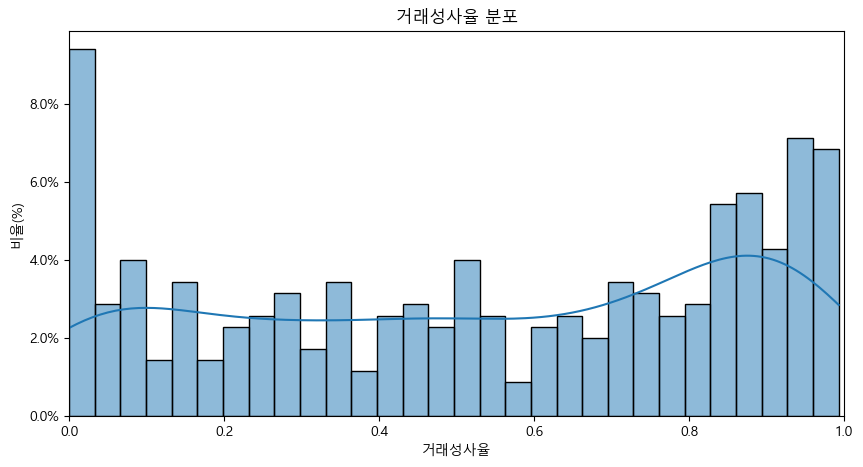

In [4]:
# 한글 폰트 설정 (Windows)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(10,5))
sns.histplot(df["거래성사율"], bins=30, kde=True, stat="probability")

plt.xlim(0, 1)
plt.xlabel("거래성사율")
plt.ylabel("비율(%)")
plt.title("거래성사율 분포")
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.show()

# 지역별 Z-score
- 지역별 거래 성사율의 평균, 표준편차를 계산

In [5]:
# 지역별 평균과 표준편차 계산
region_mean = df.groupby("지역명")["거래성사율"].transform("mean")
region_std  = df.groupby("지역명")["거래성사율"].transform("std")

# Z-score 생성  
df["Zscore"] = (df["거래성사율"] - region_mean) / (region_std)


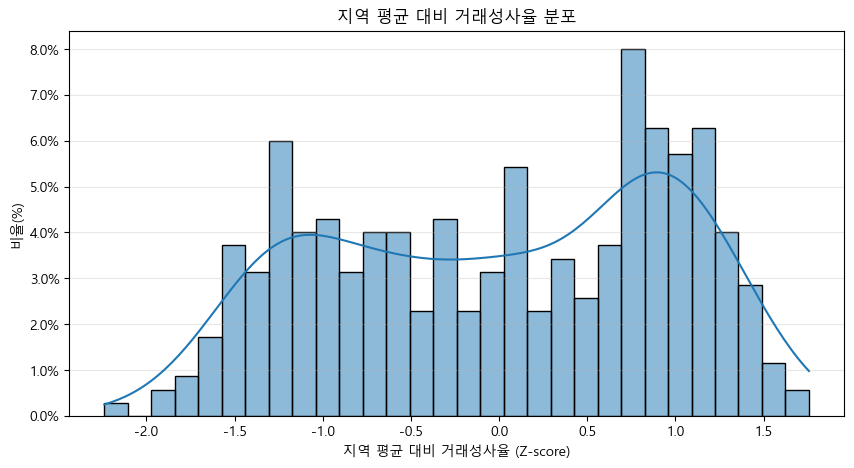

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick

plt.figure(figsize=(10,5))

sns.histplot(df["Zscore"], bins=30, kde=True, stat="probability")

plt.xlabel("지역 평균 대비 거래성사율 (Z-score)")
plt.ylabel("비율(%)")
plt.title("지역 평균 대비 거래성사율 분포")

plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.grid(axis='y', alpha=0.3)

plt.show()


#  개인성사율이 지역 평균보다 얼마나 높은지
# -------------------------------------
#  그 지역 성사율이 원래 얼마나 들쭉날쭉한가

In [7]:
# 분위수 경계 계산
q30 = df["Zscore"].quantile(0.30)
q70 = df["Zscore"].quantile(0.70)

# 등급화
def classify(z):
    if z <= q30:
        return "C"   # 하위
    elif z <= q70:
        return "B"   # 중간
    else:
        return "A"   # 상위

df["등급"] = df["Zscore"].apply(classify)


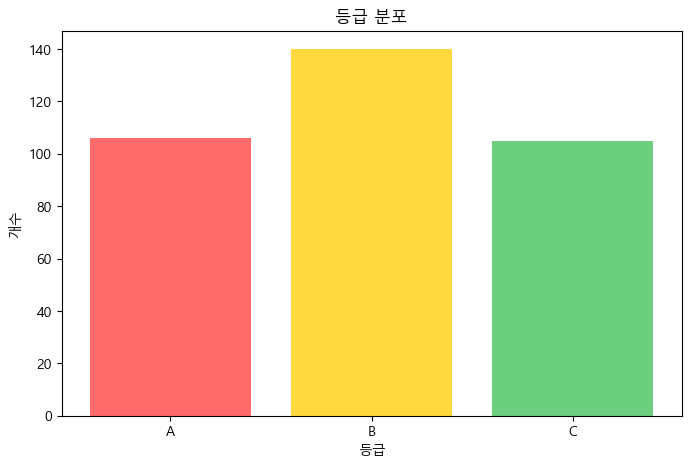

등급
A    106
B    140
C    105
Name: count, dtype: int64

비율:
등급
A    30.2
B    39.9
C    29.9
Name: count, dtype: float64%


In [8]:
import matplotlib.pyplot as plt

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'

# 등급 분포 계산
grade_counts = df["등급"].value_counts().sort_index()

# 막대 그래프
plt.figure(figsize=(8, 5))
plt.bar(grade_counts.index, grade_counts.values, 
        color=['#ff6b6b', '#ffd93d', '#6bcf7f'])
plt.title('등급 분포')
plt.xlabel('등급')
plt.ylabel('개수')
plt.show()

# 수치 출력
print(grade_counts)
print(f"\n비율:\n{(grade_counts / len(df) * 100).round(1)}%")

## 공인중개사/ 중개인/ 중개보조인/ 대표 가중치 적용 전 후 비교분석

In [9]:
# ============================================
# 가중치 적용 전/후 간단 비교 분석 (Jupyter용)
# ============================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# ============================================
# 1. 데이터 로드 및 전처리
# ============================================
print("📂 데이터 로드 중...")

# 파일 경로 찾기
possible_paths = [
    "data/brokerInfo/grouped_offices.csv",
    "../../../data/brokerInfo/grouped_offices.csv", 
    "../../../../data/brokerInfo/grouped_offices.csv"
]

data_path = None
for path in possible_paths:
    if Path(path).exists():
        data_path = path
        break

if not data_path:
    raise FileNotFoundError("grouped_offices.csv 파일을 찾을 수 없습니다!")

df = pd.read_csv(data_path, encoding="utf-8-sig")
print(f"✅ 데이터 로드: {len(df):,}개 사무소")

# 숫자 변환
if df['거래완료'].dtype == 'object':
    df['거래완료_숫자'] = df['거래완료'].str.replace(',', '').str.replace('건', '').astype(float)
else:
    df['거래완료_숫자'] = df['거래완료']
    
if df['등록매물'].dtype == 'object':
    df['등록매물_숫자'] = df['등록매물'].str.replace(',', '').str.replace('건', '').astype(float)
else:
    df['등록매물_숫자'] = df['등록매물']

# 거래성사율 및 Z-score 계산
df["거래성사율"] = np.where(
    (df["거래완료_숫자"] + df["등록매물_숫자"]) > 0,
    df["거래완료_숫자"] / (df["거래완료_숫자"] + df["등록매물_숫자"]),
    0
)

df["지역평균"] = df.groupby("지역명")["거래성사율"].transform("mean")
df["지역표준편차"] = df.groupby("지역명")["거래성사율"].transform("std").replace(0, 1e-6)
df["Zscore"] = (df["거래성사율"] - df["지역평균"]) / df["지역표준편차"]

# 대표자구분명 가중치 적용
대표자구분_가중치 = {
    '공인중개사': 0.0,
    '법인': 0.2,
    '중개보조원': -0.1,
    '중개인': -0.3,
}
df["대표자구분_조정값"] = df["대표자구분명"].map(대표자구분_가중치).fillna(-0.15)
df["Zscore_조정"] = df["Zscore"] + df["대표자구분_조정값"]

print("✅ 데이터 전처리 완료")


📂 데이터 로드 중...
✅ 데이터 로드: 382개 사무소
✅ 데이터 전처리 완료


In [10]:
# ============================================
# 2. 등급 분류 (가중치 전/후)
# ============================================

# 가중치 적용 전 (30-40-30 분위수)
q30_before = df["Zscore"].quantile(0.30)
q70_before = df["Zscore"].quantile(0.70)
df["등급_전"] = pd.cut(df["Zscore"], 
                     bins=[-np.inf, q30_before, q70_before, np.inf], 
                     labels=['C', 'B', 'A'])

# 가중치 적용 후 (30-40-30 분위수)
q30_after = df["Zscore_조정"].quantile(0.30)
q70_after = df["Zscore_조정"].quantile(0.70)
df["등급_후"] = pd.cut(df["Zscore_조정"], 
                     bins=[-np.inf, q30_after, q70_after, np.inf], 
                     labels=['C', 'B', 'A'])

# 등급 변화 계산
grade_order = {'C': 0, 'B': 1, 'A': 2}
df['등급_전_숫자'] = df['등급_전'].map(grade_order)
df['등급_후_숫자'] = df['등급_후'].map(grade_order)

df["등급변화"] = np.where(
    df['등급_후_숫자'] > df['등급_전_숫자'], "상승",
    np.where(df['등급_후_숫자'] < df['등급_전_숫자'], "하락", "유지")
)

print("✅ 등급 분류 완료")


✅ 등급 분류 완료


In [20]:
# ============================================
# 3. 결과 요약 (수정된 버전)
# ============================================
print("="*50)
print("📊 가중치 적용 전/후 비교 결과")
print("="*50)

# 전체 등급 변화
change_counts = df["등급변화"].value_counts()
total = len(df)
print(f"\n📈 전체 등급 변화:")
print(f"  상승: {change_counts.get('상승', 0):3d}개 ({change_counts.get('상승', 0)/total*100:4.1f}%)")
print(f"  유지: {change_counts.get('유지', 0):3d}개 ({change_counts.get('유지', 0)/total*100:4.1f}%)")
print(f"  하락: {change_counts.get('하락', 0):3d}개 ({change_counts.get('하락', 0)/total*100:4.1f}%)")

# 대표자구분명별 변화
print(f"\n📋 대표자구분명별 등급 변화:")
for rep_type in ['법인', '공인중개사', '중개보조원', '중개인']:
    rep_df = df[df["대표자구분명"] == rep_type]
    if len(rep_df) > 0:
        rep_changes = rep_df["등급변화"].value_counts()
        print(f"  {rep_type:8s}: 상승 {rep_changes.get('상승', 0):2d}개, "
              f"유지 {rep_changes.get('유지', 0):3d}개, 하락 {rep_changes.get('하락', 0):2d}개")

# 등급 변화 데이터 추출
upgraded = df[df["등급변화"] == "상승"]
downgraded = df[df["등급변화"] == "하락"]

print(f"\n\n🔍 등급 변화 패턴 분석:")
print("="*80)

# 상승 패턴 (등급_전, 등급_후 컬럼 사용)
if len(upgraded) > 0:
    upgrade_patterns = upgraded.groupby(['등급_전', '등급_후']).size()
    print(f"\n⬆️ 상승 패턴:")
    for (before, after), count in upgrade_patterns.items():
        print(f"  {before} → {after}: {count}개")
else:
    print(f"\n⬆️ 상승한 사무소가 없습니다.")

# 하락 패턴
if len(downgraded) > 0:
    downgrade_patterns = downgraded.groupby(['등급_전', '등급_후']).size()
    print(f"\n⬇️ 하락 패턴:")
    for (before, after), count in downgrade_patterns.items():
        print(f"  {before} → {after}: {count}개")
else:
    print(f"\n⬇️ 하락한 사무소가 없습니다.")

# 추가 분석: 등급 변화 매트릭스
print(f"\n📊 등급 변화 매트릭스:")
change_matrix = pd.crosstab(df['등급_전'], df['등급_후'], rownames=['가중치 전'], colnames=['가중치 후'])
print(change_matrix)

print("\n✅ 전체 분석 완료!")


📊 가중치 적용 전/후 비교 결과

📈 전체 등급 변화:
  상승:   2개 ( 0.5%)
  유지: 378개 (99.0%)
  하락:   2개 ( 0.5%)

📋 대표자구분명별 등급 변화:
  법인      : 상승  1개, 유지   8개, 하락  0개
  공인중개사   : 상승  1개, 유지 367개, 하락  1개
  중개보조원   : 상승  0개, 유지   1개, 하락  0개
  중개인     : 상승  0개, 유지   2개, 하락  1개


🔍 등급 변화 패턴 분석:

⬆️ 상승 패턴:
  C → C: 0개
  C → B: 1개
  C → A: 0개
  B → C: 0개
  B → B: 0개
  B → A: 1개
  A → C: 0개
  A → B: 0개
  A → A: 0개

⬇️ 하락 패턴:
  C → C: 0개
  C → B: 0개
  C → A: 0개
  B → C: 1개
  B → B: 0개
  B → A: 0개
  A → C: 0개
  A → B: 1개
  A → A: 0개

📊 등급 변화 매트릭스:
가중치 후    C    B    A
가중치 전               
C      114    1    0
B        1  150    1
A        0    1  114

✅ 전체 분석 완료!


C:\Users\Playdata\AppData\Local\Temp\ipykernel_23724\2089011092.py:34: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  upgrade_patterns = upgraded.groupby(['등급_전', '등급_후']).size()
C:\Users\Playdata\AppData\Local\Temp\ipykernel_23724\2089011092.py:43: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  downgrade_patterns = downgraded.groupby(['등급_전', '등급_후']).size()


# EDA

✅ 데이터 로드 완료: 351개 업소
📊 중개업소별 공인중개사수 분포 분석

📈 기본 통계:
  • 평균: 1.93명
  • 중앙값: 1명
  • 최소: 0명
  • 최대: 13명
  • 표준편차: 1.70명

📊 공인중개사수별 업소 수:
  • 0명: 5개 업소 (1.4%)
  • 1명: 191개 업소 (54.4%)
  • 2명: 85개 업소 (24.2%)
  • 3명: 33개 업소 (9.4%)
  • 4명: 17개 업소 (4.8%)
  • 5명: 6개 업소 (1.7%)
  • 6명: 4개 업소 (1.1%)
  • 7명: 3개 업소 (0.9%)
  • 9명: 2개 업소 (0.6%)
  • 10명: 2개 업소 (0.6%)
  • 11명: 2개 업소 (0.6%)
  • 13명: 1개 업소 (0.3%)


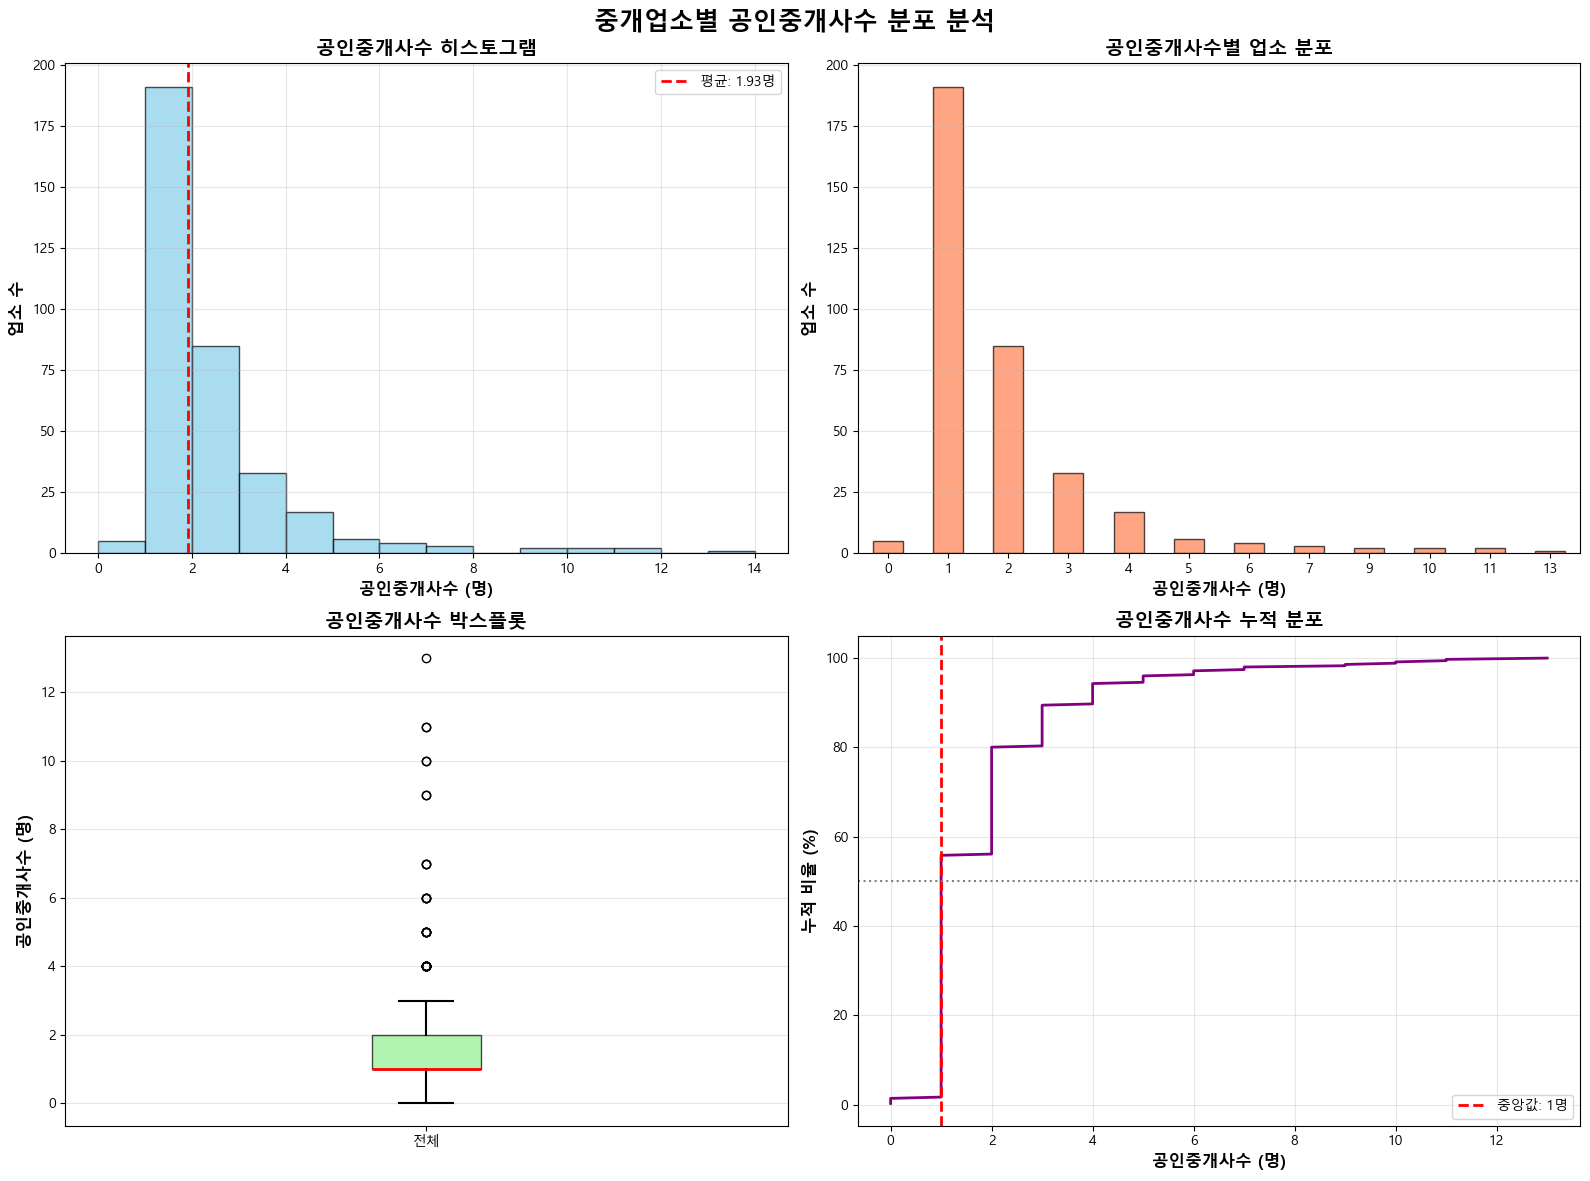


📊 공인중개사수별 평균 거래성사율:
  • 0명: 평균 성사율 0.474 (5.0개 업소)
  • 1명: 평균 성사율 0.573 (191.0개 업소)
  • 2명: 평균 성사율 0.440 (85.0개 업소)
  • 3명: 평균 성사율 0.523 (33.0개 업소)
  • 4명: 평균 성사율 0.557 (17.0개 업소)
  • 5명: 평균 성사율 0.532 (6.0개 업소)
  • 6명: 평균 성사율 0.394 (4.0개 업소)
  • 7명: 평균 성사율 0.667 (3.0개 업소)
  • 9명: 평균 성사율 0.831 (2.0개 업소)
  • 10명: 평균 성사율 0.722 (2.0개 업소)
  • 11명: 평균 성사율 0.339 (2.0개 업소)
  • 13명: 평균 성사율 0.612 (1.0개 업소)


In [5]:
# 1. 데이터 로드
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pathlib import Path

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 원본 데이터 로드
filepath = "../../../../data/ML/preprocessed_office_data.csv"
df = pd.read_csv(filepath, encoding="utf-8-sig")

print(f"✅ 데이터 로드 완료: {len(df)}개 업소")

# 2. 공인중개사수 분포 분석
print("=" * 60)
print("📊 중개업소별 공인중개사수 분포 분석")
print("=" * 60)

# 기본 통계
print(f"\n📈 기본 통계:")
print(f"  • 평균: {df['공인중개사수'].mean():.2f}명")
print(f"  • 중앙값: {df['공인중개사수'].median():.0f}명")
print(f"  • 최소: {df['공인중개사수'].min():.0f}명")
print(f"  • 최대: {df['공인중개사수'].max():.0f}명")
print(f"  • 표준편차: {df['공인중개사수'].std():.2f}명")

# 분포 확인
print(f"\n📊 공인중개사수별 업소 수:")
broker_counts = df['공인중개사수'].value_counts().sort_index()
for count, num_offices in broker_counts.items():
    percentage = (num_offices / len(df)) * 100
    print(f"  • {count}명: {num_offices}개 업소 ({percentage:.1f}%)")

# 3. 시각화
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('중개업소별 공인중개사수 분포 분석', fontsize=18, fontweight='bold', y=0.98)

# 3-1. 히스토그램
ax1 = axes[0, 0]
ax1.hist(df['공인중개사수'], bins=range(int(df['공인중개사수'].min()), 
                                      int(df['공인중개사수'].max()) + 2), 
         color='skyblue', edgecolor='black', alpha=0.7)
ax1.set_xlabel('공인중개사수 (명)', fontweight='bold', fontsize=12)
ax1.set_ylabel('업소 수', fontweight='bold', fontsize=12)
ax1.set_title('공인중개사수 히스토그램', fontweight='bold', fontsize=14)
ax1.grid(True, alpha=0.3)

# 평균선 추가
mean_val = df['공인중개사수'].mean()
ax1.axvline(mean_val, color='red', linestyle='--', linewidth=2, 
           label=f'평균: {mean_val:.2f}명')
ax1.legend()

# 3-2. 막대 그래프
ax2 = axes[0, 1]
broker_counts.plot(kind='bar', ax=ax2, color='coral', edgecolor='black', alpha=0.7)
ax2.set_xlabel('공인중개사수 (명)', fontweight='bold', fontsize=12)
ax2.set_ylabel('업소 수', fontweight='bold', fontsize=12)
ax2.set_title('공인중개사수별 업소 분포', fontweight='bold', fontsize=14)
ax2.grid(True, alpha=0.3, axis='y')
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=0)

# 3-3. 박스플롯
ax3 = axes[1, 0]
box = ax3.boxplot(df['공인중개사수'], vert=True, patch_artist=True,
                  boxprops=dict(facecolor='lightgreen', alpha=0.7),
                  medianprops=dict(color='red', linewidth=2),
                  whiskerprops=dict(linewidth=1.5),
                  capprops=dict(linewidth=1.5))
ax3.set_ylabel('공인중개사수 (명)', fontweight='bold', fontsize=12)
ax3.set_title('공인중개사수 박스플롯', fontweight='bold', fontsize=14)
ax3.grid(True, alpha=0.3, axis='y')
ax3.set_xticklabels(['전체'])

# 3-4. 누적 분포
ax4 = axes[1, 1]
sorted_data = np.sort(df['공인중개사수'])
cumulative = np.arange(1, len(sorted_data) + 1) / len(sorted_data) * 100
ax4.plot(sorted_data, cumulative, linewidth=2, color='purple')
ax4.set_xlabel('공인중개사수 (명)', fontweight='bold', fontsize=12)
ax4.set_ylabel('누적 비율 (%)', fontweight='bold', fontsize=12)
ax4.set_title('공인중개사수 누적 분포', fontweight='bold', fontsize=14)
ax4.grid(True, alpha=0.3)

# 중앙값 표시
median_val = df['공인중개사수'].median()
ax4.axvline(median_val, color='red', linestyle='--', linewidth=2,
           label=f'중앙값: {median_val:.0f}명')
ax4.axhline(50, color='gray', linestyle=':', linewidth=1.5)
ax4.legend()

plt.tight_layout()
plt.show()

# 4. 추가 분석: 공인중개사수와 거래성사율 관계
# 먼저 거래성사율 계산
def to_int(x):
    if isinstance(x, str):
        return int(x.replace("건", "").strip())
    return x

df["거래완료"] = df["거래완료_숫자"].apply(to_int)
df["등록매물"] = df["등록매물_숫자"].apply(to_int)
df["전체매물"] = df["거래완료"] + df["등록매물"]
df["거래성사율"] = np.where(
    df["전체매물"] > 0,
    df["거래완료"] / df["전체매물"],
    0
)

print(f"\n📊 공인중개사수별 평균 거래성사율:")
grouped = df.groupby('공인중개사수')['거래성사율'].agg(['mean', 'count'])
for idx, row in grouped.iterrows():
    print(f"  • {idx}명: 평균 성사율 {row['mean']:.3f} ({row['count']}개 업소)")

# 모델 평가

## 혼돈행렬

🔧 스케일러 적용 중...
✅ 스케일러 발견: <class 'sklearn.preprocessing._data.StandardScaler'>
스케일링 전 데이터 범위: 0.000 ~ 160.000
스케일링 후 데이터 범위: -4.726 ~ 9.244

🎯 올바른 예측 결과:
실제 등급 분포: 신뢰도등급
A    22
B    28
C    21
Name: count, dtype: int64
예측 등급 분포: A    27
B    19
C    25
Name: count, dtype: int64
🏆 올바른 정확도: 0.7324 (73.24%)
✅ 원래 성능 복구 성공!

📊 상세 성능 리포트:
  A등급:
    - Precision: 0.7407
    - Recall:    0.9091
    - F1-Score:  0.8163
    - Support:   22.0
  B등급:
    - Precision: 0.7368
    - Recall:    0.5000
    - F1-Score:  0.5957
    - Support:   28.0
  C등급:
    - Precision: 0.7200
    - Recall:    0.8571
    - F1-Score:  0.7826
    - Support:   21.0


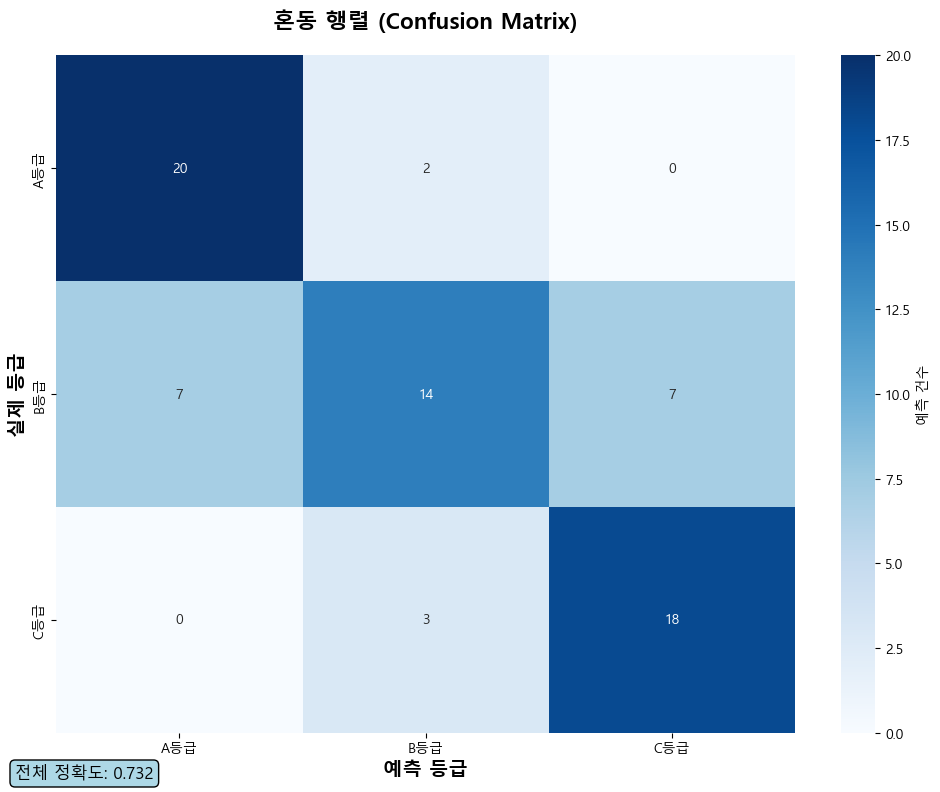

In [30]:
# 스케일러 적용해서 다시 예측
print("🔧 스케일러 적용 중...")

# 저장된 스케일러 사용
if 'scaler' in model and model['scaler'] is not None:
    scaler = model['scaler']
    print(f"✅ 스케일러 발견: {type(scaler)}")
    
    # 피처 순서 맞추기
    feature_cols = model['feature_names']
    X_test_ordered = test_data[feature_cols]
    
    # 스케일링 적용
    X_test_scaled = scaler.transform(X_test_ordered)
    print(f"스케일링 전 데이터 범위: {X_test_ordered.min().min():.3f} ~ {X_test_ordered.max().max():.3f}")
    print(f"스케일링 후 데이터 범위: {X_test_scaled.min():.3f} ~ {X_test_scaled.max():.3f}")
    
    # 올바른 예측
    y_pred_correct = actual_model.predict(X_test_scaled)
    
    print(f"\n🎯 올바른 예측 결과:")
    print(f"실제 등급 분포: {pd.Series(y_test).value_counts().sort_index()}")
    print(f"예측 등급 분포: {pd.Series(y_pred_correct).value_counts().sort_index()}")
    
    # 정확도 계산
    from sklearn.metrics import accuracy_score, classification_report
    accuracy_correct = accuracy_score(y_test, y_pred_correct)
    print(f"🏆 올바른 정확도: {accuracy_correct:.4f} ({accuracy_correct*100:.2f}%)")
    
    if accuracy_correct > 0.7:
        print("✅ 원래 성능 복구 성공!")
        
        # 상세 성능 리포트
        print(f"\n📊 상세 성능 리포트:")
        report = classification_report(y_test, y_pred_correct, output_dict=True)
        for class_name in ['A', 'B', 'C']:
            if class_name in report:
                print(f"  {class_name}등급:")
                print(f"    - Precision: {report[class_name]['precision']:.4f}")
                print(f"    - Recall:    {report[class_name]['recall']:.4f}")
                print(f"    - F1-Score:  {report[class_name]['f1-score']:.4f}")
                print(f"    - Support:   {report[class_name]['support']}")
        
        # 혼동 행렬
        from sklearn.metrics import confusion_matrix
        import matplotlib.pyplot as plt
        import seaborn as sns
        
        plt.figure(figsize=(10, 8))
        cm = confusion_matrix(y_test, y_pred_correct)
        classes = ['A등급', 'B등급', 'C등급']
        
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                    xticklabels=classes, yticklabels=classes,
                    cbar_kws={'label': '예측 건수'})
        
        plt.title('혼동 행렬 (Confusion Matrix)', fontsize=16, fontweight='bold', pad=20)
        plt.xlabel('예측 등급', fontsize=14, fontweight='bold')
        plt.ylabel('실제 등급', fontsize=14, fontweight='bold')
        
        plt.figtext(0.02, 0.02, f'전체 정확도: {accuracy_correct:.3f}', 
                    fontsize=12, bbox=dict(boxstyle="round,pad=0.3", facecolor="lightblue"))
        
        plt.tight_layout()
        plt.show()
        
        # y_pred 업데이트
        y_pred = y_pred_correct
        
    else:
        print("❌ 여전히 성능이 낮습니다. 다른 문제가 있을 수 있습니다.")

else:
    print("❌ 저장된 스케일러를 찾을 수 없습니다.")
    print("모델 딕셔너리 내용:", list(model.keys()))


📉 Loss 분석
🎯 전체 Log Loss: 0.8324

📊 등급별 분석:
  A등급: 22개 샘플, Loss 0.7491, 확신도 0.4788
  B등급: 28개 샘플, Loss 0.9992, 확신도 0.3697
  C등급: 21개 샘플, Loss 0.6973, 확신도 0.5277


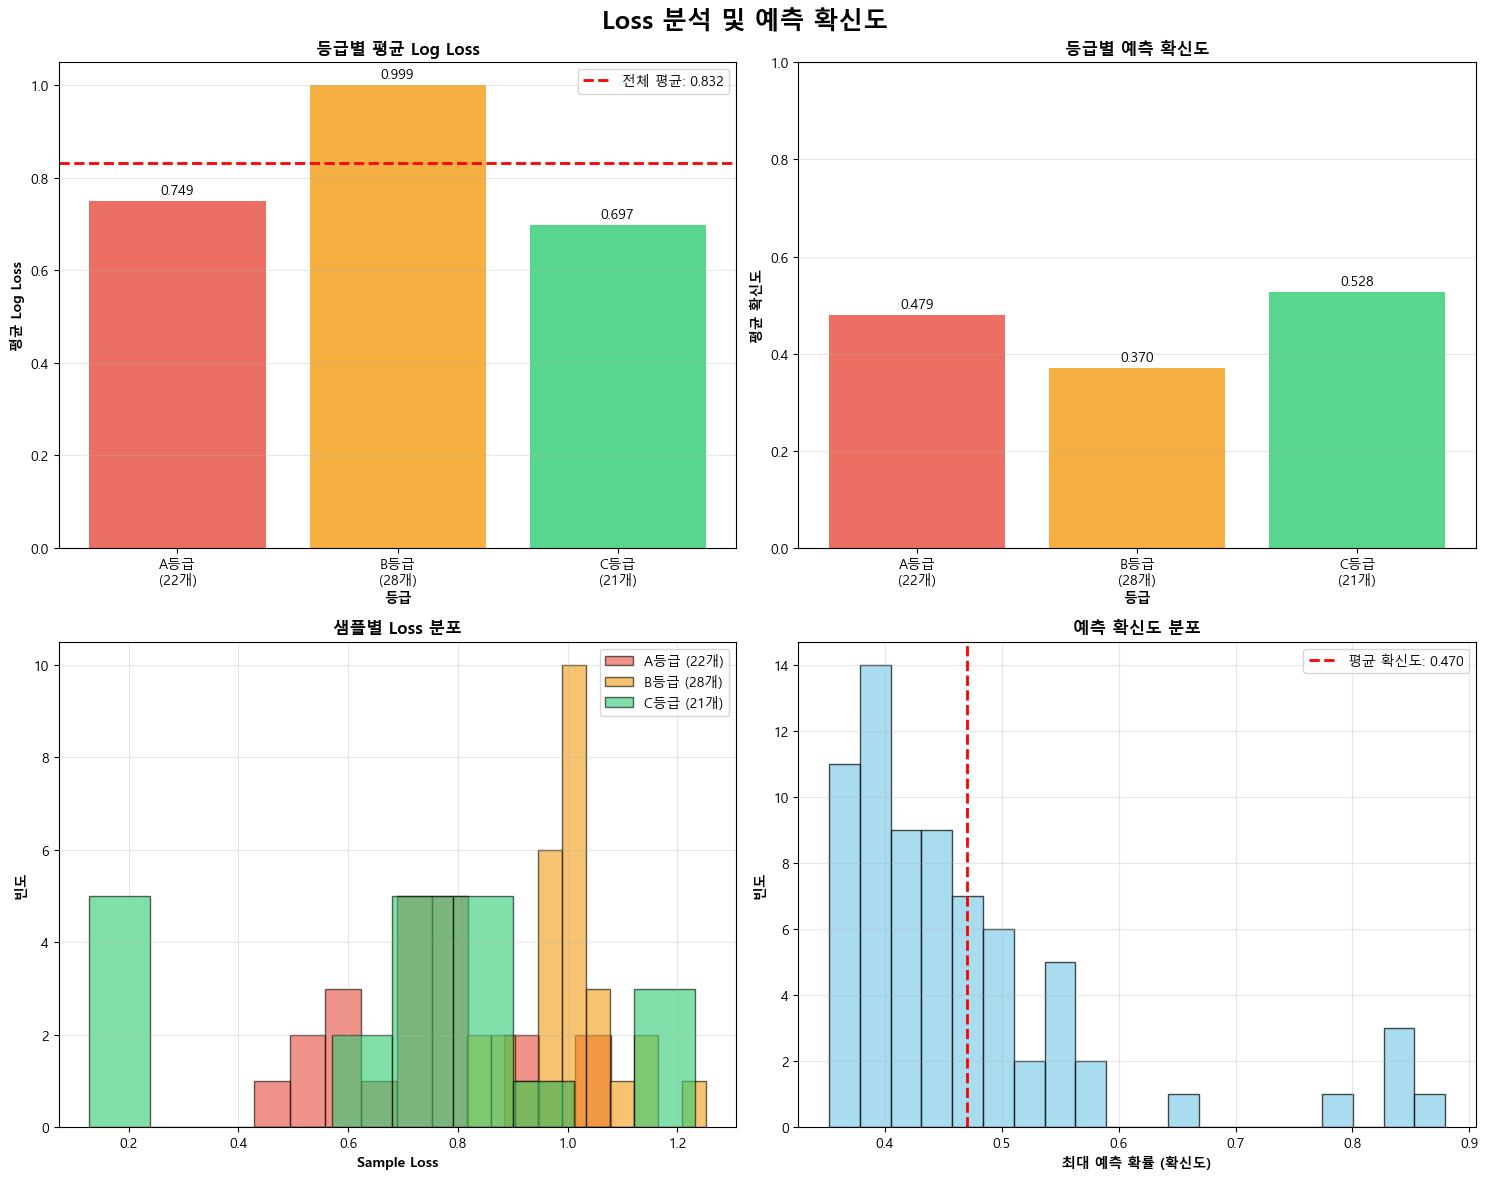


💡 Loss 분석 결과:
📊 Loss 해석:
  • 전체 Log Loss: 0.8324 (좋음)
  • Loss가 낮을수록 모델의 예측 확신도가 높고 정확함을 의미

📈 등급별 Loss 분석:
  • A등급 (22개 샘플):
    - 평균 Loss: 0.7491
    - 평균 확신도: 0.4788
    - 평가: 평균보다 낮은 Loss (예측 성능 좋음)
  • B등급 (28개 샘플):
    - 평균 Loss: 0.9992
    - 평균 확신도: 0.3697
    - 평가: 평균보다 높은 Loss (예측 어려움)
  • C등급 (21개 샘플):
    - 평균 Loss: 0.6973
    - 평균 확신도: 0.5277
    - 평가: 평균보다 낮은 Loss (예측 성능 좋음)

🎯 예측 확신도 통계:
  • 평균 확신도: 0.4702
  • 최고 확신도: 0.8793
  • 최저 확신도: 0.3525
  • 확신도 표준편차: 0.1184

  • 가장 확신도 높은 예측:
    - 확신도: 0.8793
    - 실제: C, 예측: C
  • 가장 확신도 낮은 예측:
    - 확신도: 0.3525
    - 실제: B, 예측: B

✅ Loss 분석 완료!


In [49]:
# Loss 계산 및 시각화 (수정된 버전)
from sklearn.metrics import log_loss
import matplotlib.pyplot as plt
import numpy as np

print("📉 Loss 분석")
print("="*60)

# 1. 전체 Log Loss 계산
y_pred_proba = actual_model.predict_proba(X_test_scaled)
total_loss = log_loss(y_test, y_pred_proba)

print(f"🎯 전체 Log Loss: {total_loss:.4f}")

# 2. 등급별 Loss 계산 (수정된 방법)
classes = ['A', 'B', 'C']
class_losses = []
class_confidences = []
class_sample_counts = []

print(f"\n📊 등급별 분석:")
for i, class_name in enumerate(classes):
    # 해당 클래스의 실제 샘플들
    class_mask = (y_test == class_name)
    sample_count = class_mask.sum()
    class_sample_counts.append(sample_count)
    
    if sample_count > 0:
        # 해당 클래스 예측 확신도 (해당 클래스 확률의 평균)
        class_confidence = y_pred_proba[class_mask, i].mean()
        class_confidences.append(class_confidence)
        
        # 개별 샘플 loss 계산 후 평균
        individual_losses = []
        for j in np.where(class_mask)[0]:
            true_class_idx = i
            pred_prob = y_pred_proba[j, true_class_idx]
            sample_loss = -np.log(max(pred_prob, 1e-15))  # 수치 안정성
            individual_losses.append(sample_loss)
        
        class_loss = np.mean(individual_losses)
        class_losses.append(class_loss)
        
        print(f"  {class_name}등급: {sample_count}개 샘플, Loss {class_loss:.4f}, 확신도 {class_confidence:.4f}")
    else:
        class_losses.append(0)
        class_confidences.append(0)
        print(f"  {class_name}등급: 샘플 없음")

# 3. Loss 시각화
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Loss 분석 및 예측 확신도', fontsize=18, fontweight='bold', y=0.98)

# 3-1. 등급별 Loss 비교 (샘플이 있는 등급만)
ax1 = axes[0, 0]
colors = ['#e74c3c', '#f39c12', '#2ecc71']
valid_classes = []
valid_losses = []
valid_colors = []

for i, (class_name, loss, count) in enumerate(zip(classes, class_losses, class_sample_counts)):
    if count > 0:
        valid_classes.append(f'{class_name}등급\n({count}개)')
        valid_losses.append(loss)
        valid_colors.append(colors[i])

bars = ax1.bar(valid_classes, valid_losses, color=valid_colors, alpha=0.8)
ax1.set_xlabel('등급', fontweight='bold')
ax1.set_ylabel('평균 Log Loss', fontweight='bold')
ax1.set_title('등급별 평균 Log Loss', fontweight='bold')
ax1.grid(True, alpha=0.3, axis='y')

# 막대 위에 값 표시
for bar, loss in zip(bars, valid_losses):
    height = bar.get_height()
    ax1.annotate(f'{loss:.3f}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom', fontsize=10)

# 전체 Loss 선 추가
ax1.axhline(y=total_loss, color='red', linestyle='--', linewidth=2, 
           label=f'전체 평균: {total_loss:.3f}')
ax1.legend()

# 3-2. 예측 확신도 비교
ax2 = axes[0, 1]
valid_confidences = [conf for conf, count in zip(class_confidences, class_sample_counts) if count > 0]

bars = ax2.bar(valid_classes, valid_confidences, color=valid_colors, alpha=0.8)
ax2.set_xlabel('등급', fontweight='bold')
ax2.set_ylabel('평균 확신도', fontweight='bold')
ax2.set_title('등급별 예측 확신도', fontweight='bold')
ax2.set_ylim(0, 1)
ax2.grid(True, alpha=0.3, axis='y')

# 막대 위에 값 표시
for bar, conf in zip(bars, valid_confidences):
    height = bar.get_height()
    ax2.annotate(f'{conf:.3f}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom', fontsize=10)

# 3-3. 전체 샘플별 Loss 분포
ax3 = axes[1, 0]
all_sample_losses = []
all_sample_classes = []

for i, (true_class, pred_proba) in enumerate(zip(y_test, y_pred_proba)):
    true_idx = list(classes).index(true_class)
    sample_loss = -np.log(max(pred_proba[true_idx], 1e-15))
    all_sample_losses.append(sample_loss)
    all_sample_classes.append(true_class)

# 등급별로 분리해서 히스토그램
for i, class_name in enumerate(classes):
    class_sample_losses = [loss for loss, cls in zip(all_sample_losses, all_sample_classes) if cls == class_name]
    if len(class_sample_losses) > 0:
        ax3.hist(class_sample_losses, bins=min(10, len(class_sample_losses)), 
                alpha=0.6, label=f'{class_name}등급 ({len(class_sample_losses)}개)', 
                color=colors[i], edgecolor='black')

ax3.set_xlabel('Sample Loss', fontweight='bold')
ax3.set_ylabel('빈도', fontweight='bold')
ax3.set_title('샘플별 Loss 분포', fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3)

# 3-4. 확신도 분포
ax4 = axes[1, 1]
max_probs = np.max(y_pred_proba, axis=1)
ax4.hist(max_probs, bins=20, alpha=0.7, color='skyblue', edgecolor='black')
ax4.axvline(max_probs.mean(), color='red', linestyle='--', linewidth=2, 
           label=f'평균 확신도: {max_probs.mean():.3f}')
ax4.set_xlabel('최대 예측 확률 (확신도)', fontweight='bold')
ax4.set_ylabel('빈도', fontweight='bold')
ax4.set_title('예측 확신도 분포', fontweight='bold')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 4. Loss 해석 및 분석
print(f"\n💡 Loss 분석 결과:")
print("="*60)

print(f"📊 Loss 해석:")
if total_loss < 0.5:
    loss_quality = "매우 좋음"
elif total_loss < 1.0:
    loss_quality = "좋음"
elif total_loss < 1.5:
    loss_quality = "보통"
else:
    loss_quality = "개선 필요"

print(f"  • 전체 Log Loss: {total_loss:.4f} ({loss_quality})")
print(f"  • Loss가 낮을수록 모델의 예측 확신도가 높고 정확함을 의미")

print(f"\n📈 등급별 Loss 분석:")
for i, class_name in enumerate(classes):
    if class_sample_counts[i] > 0:
        print(f"  • {class_name}등급 ({class_sample_counts[i]}개 샘플):")
        print(f"    - 평균 Loss: {class_losses[i]:.4f}")
        print(f"    - 평균 확신도: {class_confidences[i]:.4f}")
        if class_losses[i] < total_loss:
            print(f"    - 평가: 평균보다 낮은 Loss (예측 성능 좋음)")
        else:
            print(f"    - 평가: 평균보다 높은 Loss (예측 어려움)")

# 5. 확신도 통계
max_probs = np.max(y_pred_proba, axis=1)
print(f"\n🎯 예측 확신도 통계:")
print(f"  • 평균 확신도: {max_probs.mean():.4f}")
print(f"  • 최고 확신도: {max_probs.max():.4f}")
print(f"  • 최저 확신도: {max_probs.min():.4f}")
print(f"  • 확신도 표준편차: {max_probs.std():.4f}")

# 확신도가 높은/낮은 예측 찾기
high_conf_idx = np.argmax(max_probs)
low_conf_idx = np.argmin(max_probs)

print(f"\n  • 가장 확신도 높은 예측:")
print(f"    - 확신도: {max_probs[high_conf_idx]:.4f}")
print(f"    - 실제: {y_test.iloc[high_conf_idx]}, 예측: {y_pred[high_conf_idx]}")
print(f"  • 가장 확신도 낮은 예측:")
print(f"    - 확신도: {max_probs[low_conf_idx]:.4f}")
print(f"    - 실제: {y_test.iloc[low_conf_idx]}, 예측: {y_pred[low_conf_idx]}")

print(f"\n✅ Loss 분석 완료!")


## ROC 곡선

📈 ROC 곡선 생성 중...


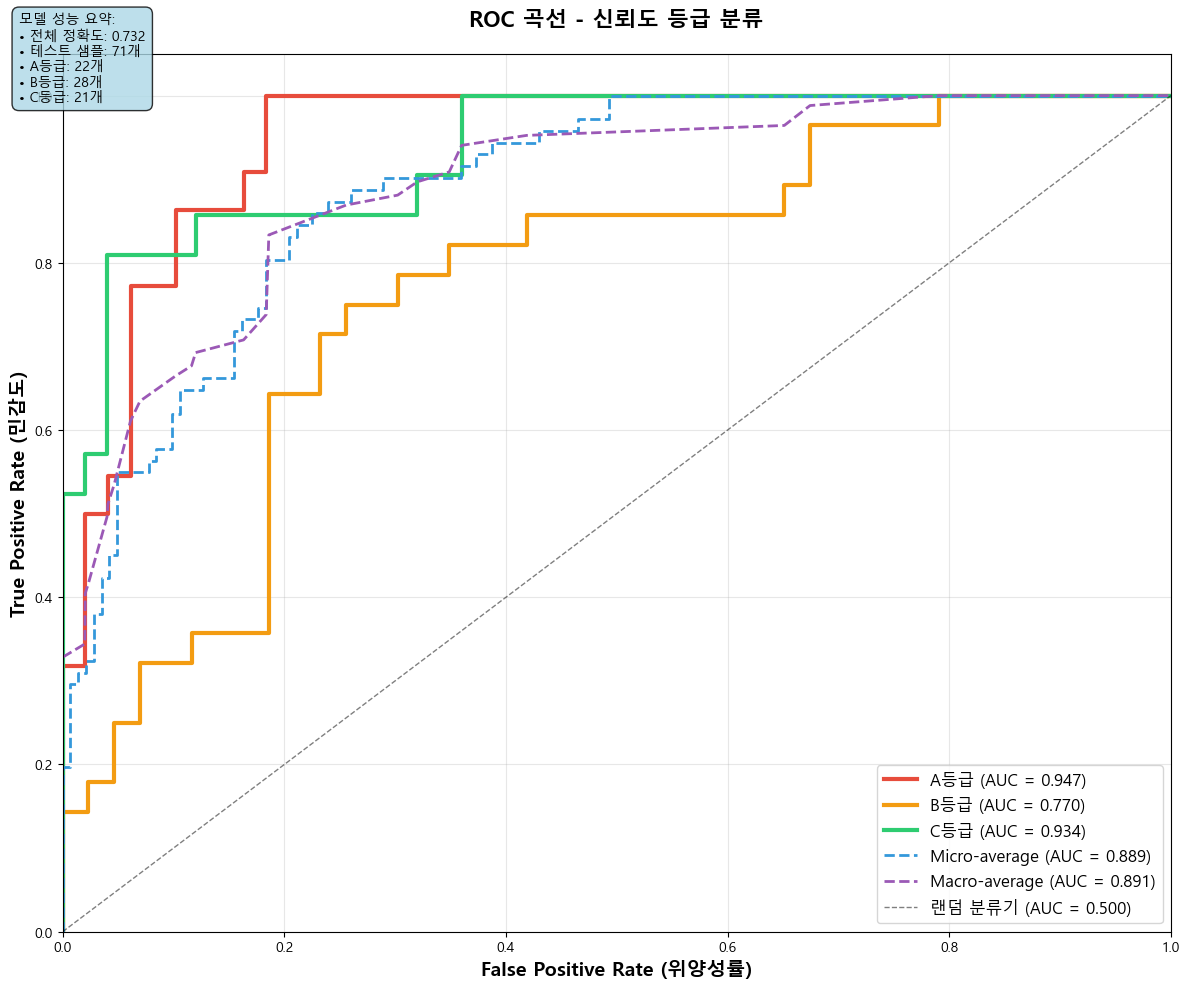


📊 AUC 점수 요약:
  A등급: 0.9471
  B등급: 0.7699
  C등급: 0.9343
  Micro-average: 0.8894
  Macro-average: 0.8909

💡 AUC 해석:
  A등급: 우수함 (AUC = 0.947)
  B등급: 보통 (AUC = 0.770)
  C등급: 우수함 (AUC = 0.934)

✅ ROC 곡선 생성 완료!


In [32]:
# ROC 곡선 그리기
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

print("📈 ROC 곡선 생성 중...")

# 예측 확률 계산 (스케일링된 데이터 사용)
y_pred_proba = actual_model.predict_proba(X_test_scaled)

# 클래스 라벨을 이진화 (다중분류 ROC를 위해)
classes = actual_model.classes_
n_classes = len(classes)

# y_test를 이진화
y_test_bin = label_binarize(y_test, classes=classes)
if n_classes == 2:
    y_test_bin = np.hstack((1 - y_test_bin, y_test_bin))

# ROC 곡선 그리기
plt.figure(figsize=(12, 10))

# 각 클래스별 ROC 곡선
colors = ['#e74c3c', '#f39c12', '#2ecc71']  # 빨강, 주황, 초록
roc_auc = {}

for i, (class_name, color) in enumerate(zip(classes, colors)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_proba[:, i])
    roc_auc[class_name] = auc(fpr, tpr)
    
    plt.plot(fpr, tpr, color=color, lw=3,
             label=f'{class_name}등급 (AUC = {roc_auc[class_name]:.3f})')

# Micro-average ROC curve
fpr_micro, tpr_micro, _ = roc_curve(y_test_bin.ravel(), y_pred_proba.ravel())
roc_auc_micro = auc(fpr_micro, tpr_micro)

plt.plot(fpr_micro, tpr_micro, color='#3498db', linestyle='--', lw=2,
         label=f'Micro-average (AUC = {roc_auc_micro:.3f})')

# Macro-average ROC curve
all_fpr = np.unique(np.concatenate([roc_curve(y_test_bin[:, i], y_pred_proba[:, i])[0] 
                                   for i in range(n_classes)]))
mean_tpr = np.zeros_like(all_fpr)

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_proba[:, i])
    mean_tpr += np.interp(all_fpr, fpr, tpr)

mean_tpr /= n_classes
roc_auc_macro = auc(all_fpr, mean_tpr)

plt.plot(all_fpr, mean_tpr, color='#9b59b6', linestyle='--', lw=2,
         label=f'Macro-average (AUC = {roc_auc_macro:.3f})')

# 대각선 (랜덤 분류기)
plt.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5, label='랜덤 분류기 (AUC = 0.500)')

# 그래프 설정
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (위양성률)', fontsize=14, fontweight='bold')
plt.ylabel('True Positive Rate (민감도)', fontsize=14, fontweight='bold')
plt.title('ROC 곡선 - 신뢰도 등급 분류', fontsize=16, fontweight='bold', pad=20)
plt.legend(loc="lower right", fontsize=12)
plt.grid(True, alpha=0.3)

# 성능 정보 텍스트 박스
info_text = f"""모델 성능 요약:
• 전체 정확도: {accuracy_correct:.3f}
• 테스트 샘플: {len(y_test)}개
• A등급: {(y_test == 'A').sum()}개
• B등급: {(y_test == 'B').sum()}개  
• C등급: {(y_test == 'C').sum()}개"""

plt.figtext(0.02, 0.98, info_text, fontsize=10, 
            bbox=dict(boxstyle="round,pad=0.5", facecolor="lightblue", alpha=0.8),
            verticalalignment='top')

plt.tight_layout()
plt.show()

# AUC 점수 요약
print(f"\n📊 AUC 점수 요약:")
for class_name in classes:
    print(f"  {class_name}등급: {roc_auc[class_name]:.4f}")
print(f"  Micro-average: {roc_auc_micro:.4f}")
print(f"  Macro-average: {roc_auc_macro:.4f}")

# AUC 해석
print(f"\n💡 AUC 해석:")
for class_name in classes:
    auc_score = roc_auc[class_name]
    if auc_score >= 0.9:
        interpretation = "우수함"
    elif auc_score >= 0.8:
        interpretation = "좋음"
    elif auc_score >= 0.7:
        interpretation = "보통"
    elif auc_score >= 0.6:
        interpretation = "약간 좋음"
    else:
        interpretation = "개선 필요"
    
    print(f"  {class_name}등급: {interpretation} (AUC = {auc_score:.3f})")

print(f"\n✅ ROC 곡선 생성 완료!")


📊 등급별 성능지표 계산 및 시각화

📋 등급별 성능지표:
    등급  Precision  Recall  F1-Score  Support  Predicted
0  A등급     0.7407  0.9091    0.8163       22         27
1  B등급     0.7368  0.5000    0.5957       28         19
2  C등급     0.7200  0.8571    0.7826       21         25

📈 등급별 상세 분석:

🏷️ A등급 분석:
   • Precision: 0.7407 - 예측한 A등급 중 74.1%가 실제 A등급
   • Recall:    0.9091 - 실제 A등급 중 90.9%를 올바르게 예측
   • F1-Score:  0.8163 - Precision과 Recall의 조화평균
   • Support:   22개 - 실제 A등급 사무소 수
   • Predicted: 27개 - A등급으로 예측된 사무소 수
   • 종합 평가: 우수 (F1-Score 기준)

🏷️ B등급 분석:
   • Precision: 0.7368 - 예측한 B등급 중 73.7%가 실제 B등급
   • Recall:    0.5000 - 실제 B등급 중 50.0%를 올바르게 예측
   • F1-Score:  0.5957 - Precision과 Recall의 조화평균
   • Support:   28개 - 실제 B등급 사무소 수
   • Predicted: 19개 - B등급으로 예측된 사무소 수
   • 종합 평가: 개선 필요 (F1-Score 기준)

🏷️ C등급 분석:
   • Precision: 0.7200 - 예측한 C등급 중 72.0%가 실제 C등급
   • Recall:    0.8571 - 실제 C등급 중 85.7%를 올바르게 예측
   • F1-Score:  0.7826 - Precision과 Recall의 조화평균
   • Support:   21개 - 실제 C등급 사무소 수
   • Predi

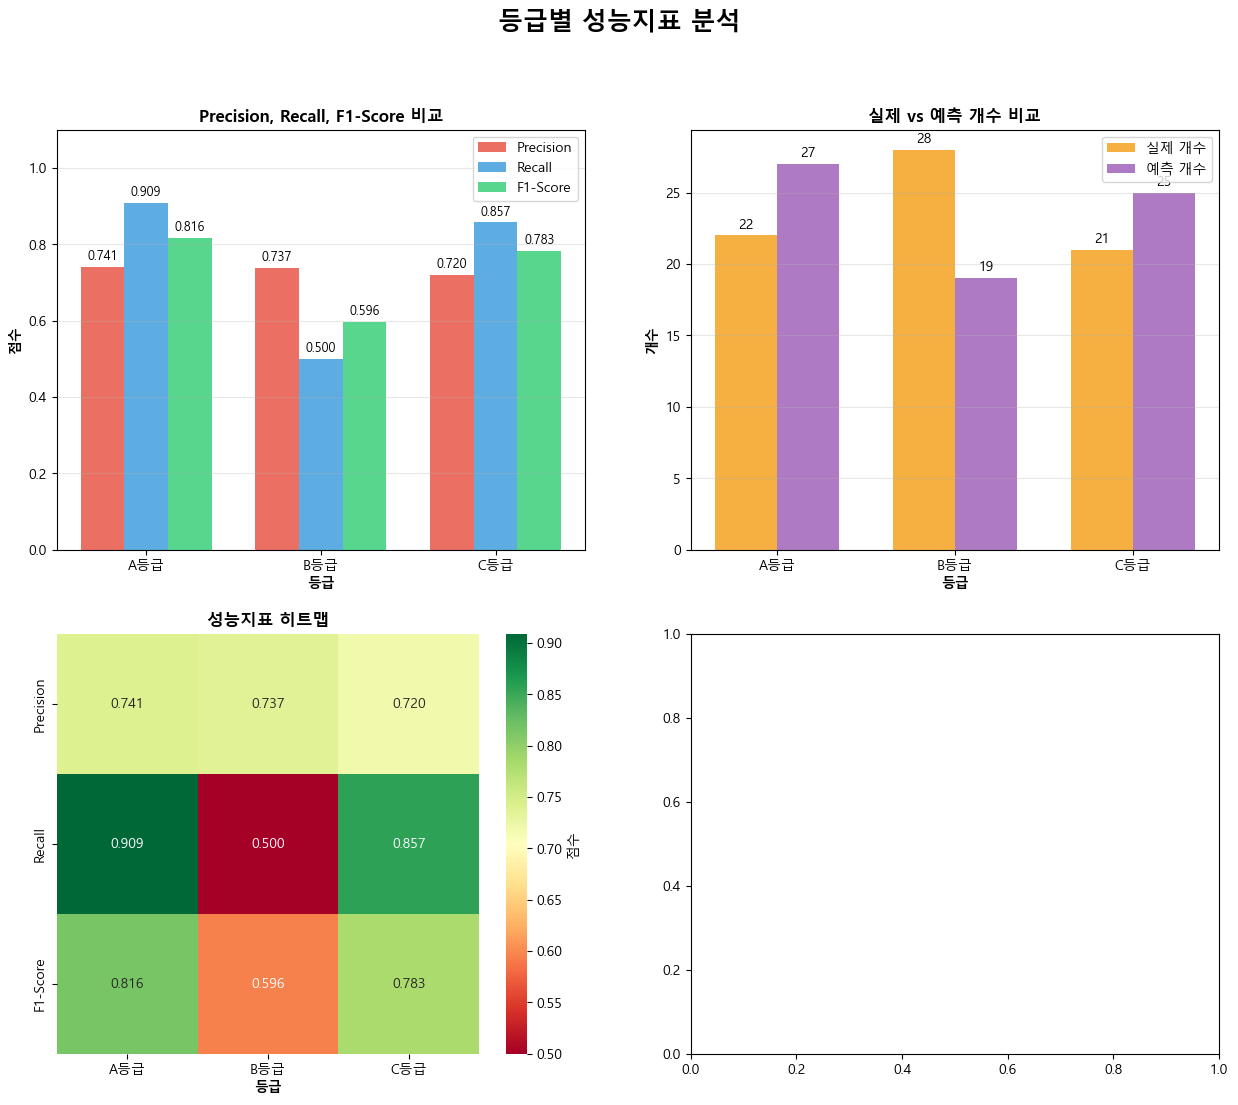

In [34]:
# 등급별 성능지표 계산 및 시각화
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report

print("📊 등급별 성능지표 계산 및 시각화")
print("="*60)

# 1. 등급별 성능지표 계산
classes = ['A', 'B', 'C']
metrics_data = []

for class_name in classes:
    # 이진 분류로 변환 (해당 클래스 vs 나머지)
    y_true_binary = (y_test == class_name).astype(int)
    y_pred_binary = (y_pred == class_name).astype(int)
    
    # 성능 지표 계산
    precision = precision_score(y_true_binary, y_pred_binary, zero_division=0)
    recall = recall_score(y_true_binary, y_pred_binary, zero_division=0)
    f1 = f1_score(y_true_binary, y_pred_binary, zero_division=0)
    
    # Support (실제 해당 클래스 개수)
    support = (y_test == class_name).sum()
    
    # 예측된 개수
    predicted_count = (y_pred == class_name).sum()
    
    metrics_data.append({
        '등급': f'{class_name}등급',
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'Support': support,
        'Predicted': predicted_count
    })

# DataFrame 생성
metrics_df = pd.DataFrame(metrics_data)
print("\n📋 등급별 성능지표:")
print(metrics_df.round(4))

# 2. 시각화 - 성능지표 비교 차트
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('등급별 성능지표 분석', fontsize=18, fontweight='bold', y=0.98)

# 2-1. Precision, Recall, F1-Score 비교
ax1 = axes[0, 0]
x = np.arange(len(classes))
width = 0.25

bars1 = ax1.bar(x - width, metrics_df['Precision'], width, label='Precision', 
                color='#e74c3c', alpha=0.8)
bars2 = ax1.bar(x, metrics_df['Recall'], width, label='Recall', 
                color='#3498db', alpha=0.8)
bars3 = ax1.bar(x + width, metrics_df['F1-Score'], width, label='F1-Score', 
                color='#2ecc71', alpha=0.8)

ax1.set_xlabel('등급', fontweight='bold')
ax1.set_ylabel('점수', fontweight='bold')
ax1.set_title('Precision, Recall, F1-Score 비교', fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels([f'{c}등급' for c in classes])
ax1.legend()
ax1.grid(True, alpha=0.3, axis='y')
ax1.set_ylim(0, 1.1)

# 막대 위에 값 표시
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax1.annotate(f'{height:.3f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9)

# 2-2. Support vs Predicted 비교
ax2 = axes[0, 1]
x = np.arange(len(classes))
width = 0.35

bars1 = ax2.bar(x - width/2, metrics_df['Support'], width, label='실제 개수', 
                color='#f39c12', alpha=0.8)
bars2 = ax2.bar(x + width/2, metrics_df['Predicted'], width, label='예측 개수', 
                color='#9b59b6', alpha=0.8)

ax2.set_xlabel('등급', fontweight='bold')
ax2.set_ylabel('개수', fontweight='bold')
ax2.set_title('실제 vs 예측 개수 비교', fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels([f'{c}등급' for c in classes])
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')

# 막대 위에 값 표시
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax2.annotate(f'{int(height)}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=10)

# 2-3. 성능지표 히트맵
ax3 = axes[1, 0]
heatmap_data = metrics_df[['Precision', 'Recall', 'F1-Score']].T
sns.heatmap(heatmap_data, annot=True, fmt='.3f', cmap='RdYlGn', 
            xticklabels=[f'{c}등급' for c in classes],
            yticklabels=['Precision', 'Recall', 'F1-Score'],
            ax=ax3, cbar_kws={'label': '점수'})
ax3.set_title('성능지표 히트맵', fontweight='bold')
ax3.set_xlabel('등급', fontweight='bold')

# # 2-4. 등급별 성능 레이더 차트
# ax4 = axes[1, 1]
# angles = np.linspace(0, 2 * np.pi, len(classes), endpoint=False).tolist()
# angles += angles[:1]  # 원형으로 만들기

# colors = ['#e74c3c', '#3498db', '#2ecc71']
# metrics_names = ['Precision', 'Recall', 'F1-Score']

# for i, metric in enumerate(metrics_names):
#     values = metrics_df[metric].tolist()
#     values += values[:1]  # 원형으로 만들기
    
#     ax4.plot(angles, values, 'o-', linewidth=2, label=metric, color=colors[i])
#     ax4.fill(angles, values, alpha=0.25, color=colors[i])

# ax4.set_xticks(angles[:-1])
# ax4.set_xticklabels([f'{c}등급' for c in classes])
# ax4.set_ylim(0, 1)
# ax4.set_title('등급별 성능 레이더 차트', fontweight='bold')
# ax4.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))
# ax4.grid(True)

# plt.tight_layout()
# plt.show()

# 3. 상세 분석 리포트
print(f"\n📈 등급별 상세 분석:")
print("="*60)

for i, class_name in enumerate(classes):
    precision = metrics_df.iloc[i]['Precision']
    recall = metrics_df.iloc[i]['Recall']
    f1 = metrics_df.iloc[i]['F1-Score']
    support = metrics_df.iloc[i]['Support']
    predicted = metrics_df.iloc[i]['Predicted']
    
    print(f"\n🏷️ {class_name}등급 분석:")
    print(f"   • Precision: {precision:.4f} - 예측한 {class_name}등급 중 {precision*100:.1f}%가 실제 {class_name}등급")
    print(f"   • Recall:    {recall:.4f} - 실제 {class_name}등급 중 {recall*100:.1f}%를 올바르게 예측")
    print(f"   • F1-Score:  {f1:.4f} - Precision과 Recall의 조화평균")
    print(f"   • Support:   {support}개 - 실제 {class_name}등급 사무소 수")
    print(f"   • Predicted: {predicted}개 - {class_name}등급으로 예측된 사무소 수")
    
    # 성능 평가
    if f1 >= 0.8:
        performance = "우수"
    elif f1 >= 0.7:
        performance = "좋음"
    elif f1 >= 0.6:
        performance = "보통"
    elif f1 >= 0.5:
        performance = "개선 필요"
    else:
        performance = "매우 개선 필요"
    
    print(f"   • 종합 평가: {performance} (F1-Score 기준)")

# 4. 전체 성능 요약
print(f"\n🎯 전체 성능 요약:")
print("="*60)
macro_precision = metrics_df['Precision'].mean()
macro_recall = metrics_df['Recall'].mean()
macro_f1 = metrics_df['F1-Score'].mean()

weighted_precision = np.average(metrics_df['Precision'], weights=metrics_df['Support'])
weighted_recall = np.average(metrics_df['Recall'], weights=metrics_df['Support'])
weighted_f1 = np.average(metrics_df['F1-Score'], weights=metrics_df['Support'])

print(f"📊 Macro 평균 (각 클래스 동등 가중):")
print(f"   • Precision: {macro_precision:.4f}")
print(f"   • Recall:    {macro_recall:.4f}")
print(f"   • F1-Score:  {macro_f1:.4f}")

print(f"\n📊 Weighted 평균 (샘플 수 가중):")
print(f"   • Precision: {weighted_precision:.4f}")
print(f"   • Recall:    {weighted_recall:.4f}")
print(f"   • F1-Score:  {weighted_f1:.4f}")

print(f"\n✅ 등급별 성능지표 분석 완료!")


# feature 상관관계

In [40]:
# ============================================
# 피처 상관관계 분석
# ============================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, spearmanr
import pickle

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# ============================================
# 1. 데이터 로드
# ============================================
print("📂 피처 데이터 로드 중...")

# 모델에서 사용된 피처 데이터 로드
MODEL_PATH = "../../../../apps/reco/models/trust_model/save_models/temp_trained_models.pkl"
with open(MODEL_PATH, "rb") as f:
    temp_data = pickle.load(f)

feature_names = temp_data["feature_names"]
X_train_scaled = temp_data["X_train_scaled"]
X_test_scaled = temp_data["X_test_scaled"]

# 전체 데이터 결합 (스케일링된 데이터)
X_all_scaled = np.vstack([X_train_scaled, X_test_scaled])
df_scaled = pd.DataFrame(X_all_scaled, columns=feature_names)

print(f"✅ 피처 수: {len(feature_names)}개")
print(f"✅ 전체 샘플 수: {len(df_scaled)}개")

# 원본 피처 데이터도 로드 (해석을 위해)
FEATURE_PATH = "../../../../data/ML/office_features.csv"
df_original = pd.read_csv(FEATURE_PATH, encoding="utf-8-sig")
df_features_original = df_original[feature_names]

print("✅ 원본 피처 데이터 로드 완료")


📂 피처 데이터 로드 중...
✅ 피처 수: 16개
✅ 전체 샘플 수: 351개
✅ 원본 피처 데이터 로드 완료


In [41]:
# ============================================
# 피처 상관관계 분석
# ============================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, spearmanr
import pickle

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# ============================================
# 1. 데이터 로드
# ============================================
print("📂 피처 데이터 로드 중...")

# 모델에서 사용된 피처 데이터 로드
MODEL_PATH = "../../../../apps/reco/models/trust_model/save_models/temp_trained_models.pkl"
with open(MODEL_PATH, "rb") as f:
    temp_data = pickle.load(f)

feature_names = temp_data["feature_names"]
X_train_scaled = temp_data["X_train_scaled"]
X_test_scaled = temp_data["X_test_scaled"]

# 전체 데이터 결합 (스케일링된 데이터)
X_all_scaled = np.vstack([X_train_scaled, X_test_scaled])
df_scaled = pd.DataFrame(X_all_scaled, columns=feature_names)

print(f"✅ 피처 수: {len(feature_names)}개")
print(f"✅ 전체 샘플 수: {len(df_scaled)}개")

# 원본 피처 데이터도 로드 (해석을 위해)
FEATURE_PATH = "../../../../data/ML/office_features.csv"
df_original = pd.read_csv(FEATURE_PATH, encoding="utf-8-sig")
df_features_original = df_original[feature_names]

print("✅ 원본 피처 데이터 로드 완료")


📂 피처 데이터 로드 중...
✅ 피처 수: 16개
✅ 전체 샘플 수: 351개
✅ 원본 피처 데이터 로드 완료


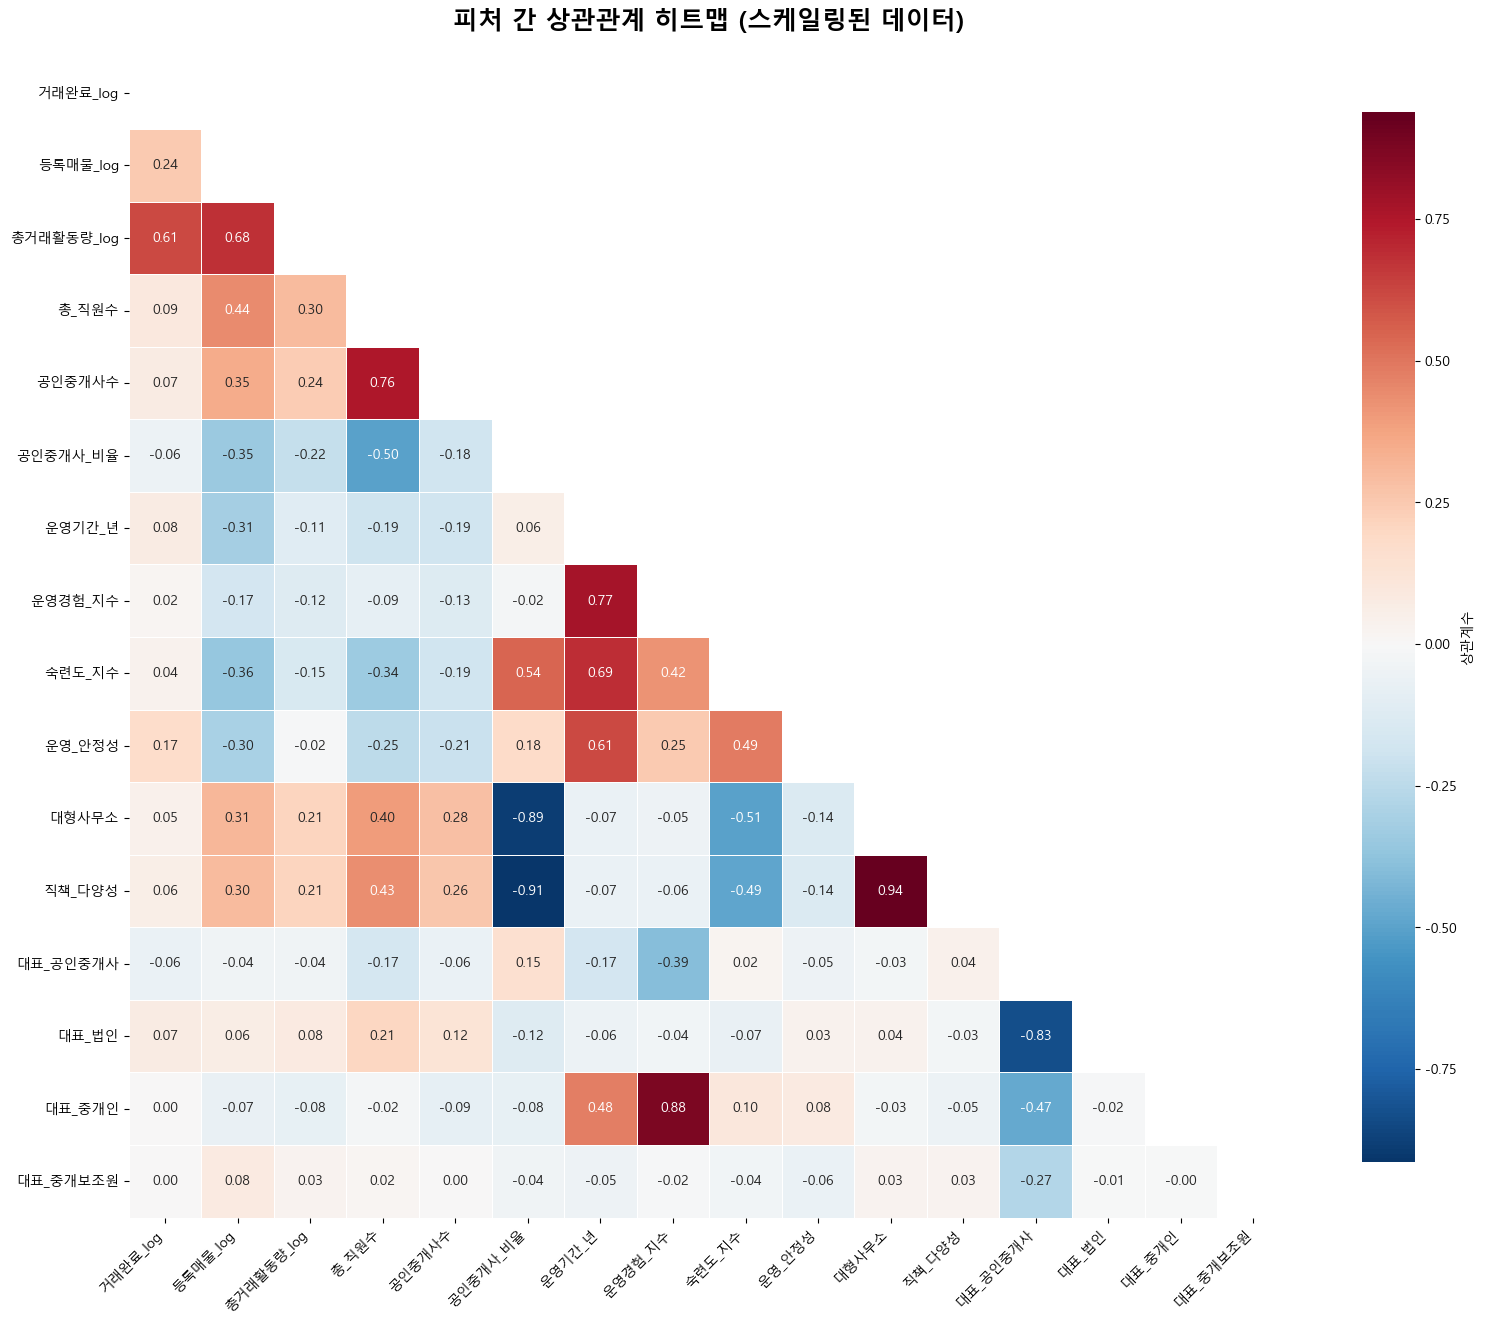

In [42]:
# ============================================
# 2. 상관관계 히트맵 (스케일링된 데이터)
# ============================================
plt.figure(figsize=(16, 14))

# 상관관계 계산
correlation_matrix = df_scaled.corr()

# 마스크 생성 (상삼각형 숨기기)
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

# 히트맵 생성
sns.heatmap(correlation_matrix, 
            mask=mask,
            annot=True, 
            fmt='.2f', 
            cmap='RdBu_r', 
            center=0,
            square=True,
            cbar_kws={'label': '상관계수', 'shrink': 0.8},
            linewidths=0.5,
            linecolor='white')

plt.title('피처 간 상관관계 히트맵 (스케일링된 데이터)', fontsize=18, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.show()


In [43]:
# ============================================
# 비즈니스 타당성 검증 분석
# ============================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# ============================================
# 1. 데이터 로드
# ============================================
print("📂 데이터 로드 중...")

# 피처 데이터 (원본 값들이 포함된 데이터)
df_features = pd.read_csv("../../../../data/ML/office_features.csv", encoding="utf-8-sig")
print(f"✅ 피처 데이터: {len(df_features)}개 사무소")

# 기본 통계
print(f"\n📊 등급 분포:")
grade_counts = df_features['신뢰도등급'].value_counts().sort_index()
for grade, count in grade_counts.items():
    print(f"  {grade}등급: {count}개 ({count/len(df_features)*100:.1f}%)")


📂 데이터 로드 중...
✅ 피처 데이터: 351개 사무소

📊 등급 분포:
  A등급: 106개 (30.2%)
  B등급: 140개 (39.9%)
  C등급: 105개 (29.9%)



📈 운영 기간 vs 신뢰도 관계 분석
📊 운영 기간별 등급 분포:
신뢰도등급     A   B   C
운영기간_구간            
1년 미만     1   8  10
1-3년      7  21  29
3-5년      9  13  11
5-10년    23  35  19
10년 이상   66  63  36

📊 운영 기간별 등급 비율 (%):
신뢰도등급       A     B     C
운영기간_구간                  
1년 미만     5.3  42.1  52.6
1-3년     12.3  36.8  50.9
3-5년     27.3  39.4  33.3
5-10년    29.9  45.5  24.7
10년 이상   40.0  38.2  21.8

🔍 카이제곱 검정 결과:
  - 카이제곱 통계량: 32.295
  - p-value: 0.000082
  - 유의성: 유의함 (p<0.05)


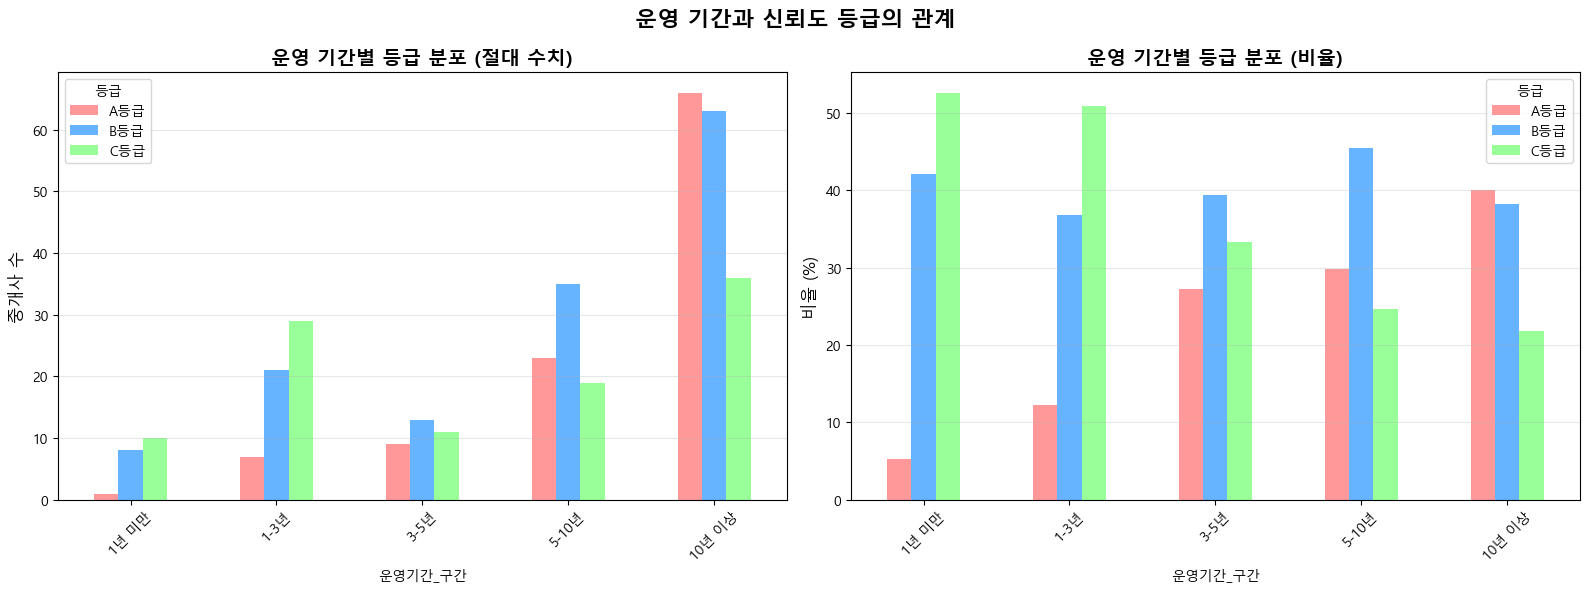


📈 운영 기간별 A등급 비율 트렌드:
  1년 미만: 5.3%
  1-3년: 12.3%
  3-5년: 27.3%
  5-10년: 29.9%
  10년 이상: 40.0%


In [44]:
# ============================================
# 2. 운영 기간 vs 신뢰도 관계 분석
# ============================================
print("\n" + "="*70)
print("📈 운영 기간 vs 신뢰도 관계 분석")
print("="*70)

# 운영 기간 구간별 분석
df_features['운영기간_구간'] = pd.cut(df_features['운영기간_년'], 
                               bins=[0, 1, 3, 5, 10, float('inf')],
                               labels=['1년 미만', '1-3년', '3-5년', '5-10년', '10년 이상'])

# 구간별 등급 분포
period_grade_crosstab = pd.crosstab(df_features['운영기간_구간'], df_features['신뢰도등급'])
period_grade_pct = period_grade_crosstab.div(period_grade_crosstab.sum(axis=1), axis=0) * 100

print("📊 운영 기간별 등급 분포:")
print(period_grade_crosstab)
print("\n📊 운영 기간별 등급 비율 (%):")
print(period_grade_pct.round(1))

# 통계적 유의성 검정
chi2, p_value = stats.chi2_contingency(period_grade_crosstab)[:2]
print(f"\n🔍 카이제곱 검정 결과:")
print(f"  - 카이제곱 통계량: {chi2:.3f}")
print(f"  - p-value: {p_value:.6f}")
print(f"  - 유의성: {'유의함 (p<0.05)' if p_value < 0.05 else '유의하지 않음 (p≥0.05)'}")

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 절대 수치
period_grade_crosstab.plot(kind='bar', ax=axes[0], color=['#ff9999', '#66b3ff', '#99ff99'])
axes[0].set_title('운영 기간별 등급 분포 (절대 수치)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('중개사 수', fontsize=12)
axes[0].legend(title='등급', labels=['A등급', 'B등급', 'C등급'])
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(True, alpha=0.3, axis='y')

# 비율
period_grade_pct.plot(kind='bar', ax=axes[1], color=['#ff9999', '#66b3ff', '#99ff99'])
axes[1].set_title('운영 기간별 등급 분포 (비율)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('비율 (%)', fontsize=12)
axes[1].legend(title='등급', labels=['A등급', 'B등급', 'C등급'])
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(True, alpha=0.3, axis='y')

plt.suptitle('운영 기간과 신뢰도 등급의 관계', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# 트렌드 분석
print(f"\n📈 운영 기간별 A등급 비율 트렌드:")
for period in period_grade_pct.index:
    a_ratio = period_grade_pct.loc[period, 'A']
    print(f"  {period}: {a_ratio:.1f}%")



🏢 조직 규모 vs 등급 상관관계 분석
📊 직원 규모별 등급 분포:
신뢰도등급     A    B   C
직원규모_구간             
2명       22   34  15
4-5명      0    0   3
6명 이상    84  105  87

📊 직원 규모별 등급 비율 (%):
신뢰도등급       A     B      C
직원규모_구간                   
2명       31.0  47.9   21.1
4-5명      0.0   0.0  100.0
6명 이상    30.4  38.0   31.5

🔍 직원 수와 등급의 상관관계:
  - 피어슨 상관계수: 0.015

🔍 카이제곱 검정 결과:
  - 카이제곱 통계량: 10.478
  - p-value: 0.033099
  - 유의성: 유의함 (p<0.05)


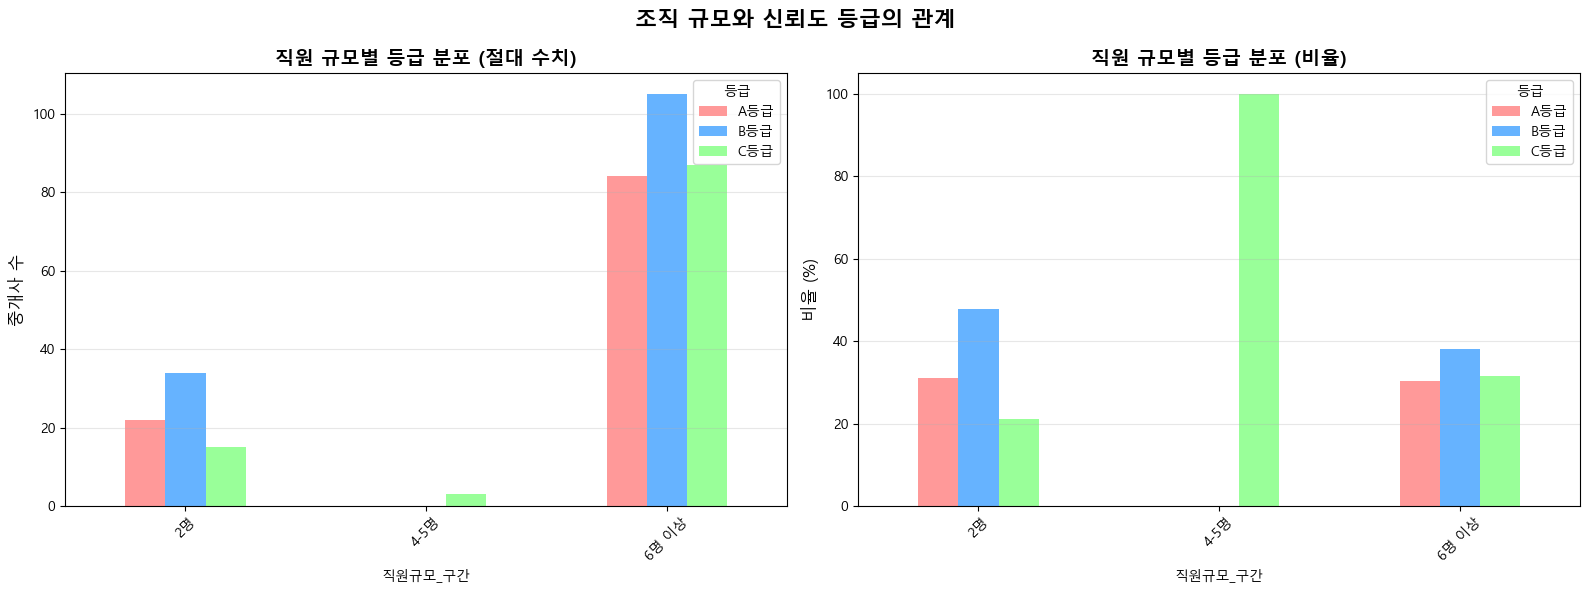


📊 등급별 평균 직원 수:
  A등급: 16.1명
  B등급: 15.5명
  C등급: 15.4명


In [45]:
# ============================================
# 3. 조직 규모 vs 등급 상관관계 분석
# ============================================
print("\n" + "="*70)
print("🏢 조직 규모 vs 등급 상관관계 분석")
print("="*70)

# 직원 수 구간별 분석
df_features['직원규모_구간'] = pd.cut(df_features['총_직원수'], 
                               bins=[0, 1, 2, 3, 5, float('inf')],
                               labels=['1명', '2명', '3명', '4-5명', '6명 이상'])

# 구간별 등급 분포
staff_grade_crosstab = pd.crosstab(df_features['직원규모_구간'], df_features['신뢰도등급'])
staff_grade_pct = staff_grade_crosstab.div(staff_grade_crosstab.sum(axis=1), axis=0) * 100

print("📊 직원 규모별 등급 분포:")
print(staff_grade_crosstab)
print("\n📊 직원 규모별 등급 비율 (%):")
print(staff_grade_pct.round(1))

# 상관관계 분석
correlation_staff_grade = df_features['총_직원수'].corr(df_features['신뢰도등급_숫자'])
print(f"\n🔍 직원 수와 등급의 상관관계:")
print(f"  - 피어슨 상관계수: {correlation_staff_grade:.3f}")

# 통계적 유의성 검정
chi2_staff, p_value_staff = stats.chi2_contingency(staff_grade_crosstab)[:2]
print(f"\n🔍 카이제곱 검정 결과:")
print(f"  - 카이제곱 통계량: {chi2_staff:.3f}")
print(f"  - p-value: {p_value_staff:.6f}")
print(f"  - 유의성: {'유의함 (p<0.05)' if p_value_staff < 0.05 else '유의하지 않음 (p≥0.05)'}")

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 절대 수치
staff_grade_crosstab.plot(kind='bar', ax=axes[0], color=['#ff9999', '#66b3ff', '#99ff99'])
axes[0].set_title('직원 규모별 등급 분포 (절대 수치)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('중개사 수', fontsize=12)
axes[0].legend(title='등급', labels=['A등급', 'B등급', 'C등급'])
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(True, alpha=0.3, axis='y')

# 비율
staff_grade_pct.plot(kind='bar', ax=axes[1], color=['#ff9999', '#66b3ff', '#99ff99'])
axes[1].set_title('직원 규모별 등급 분포 (비율)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('비율 (%)', fontsize=12)
axes[1].legend(title='등급', labels=['A등급', 'B등급', 'C등급'])
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(True, alpha=0.3, axis='y')

plt.suptitle('조직 규모와 신뢰도 등급의 관계', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# 평균 분석
print(f"\n📊 등급별 평균 직원 수:")
for grade in ['A', 'B', 'C']:
    avg_staff = df_features[df_features['신뢰도등급'] == grade]['총_직원수'].mean()
    print(f"  {grade}등급: {avg_staff:.1f}명")



👨‍💼 대표자 자격 vs 성과 연관성 분석
📊 대표자 구분별 등급 분포:
신뢰도등급     A    B    C
대표자구분명               
공인중개사   100  136  102
법인        5    4    0
중개보조원     0    0    1
중개인       1    0    2

📊 대표자 구분별 등급 비율 (%):
신뢰도등급      A     B      C
대표자구분명                   
공인중개사   29.6  40.2   30.2
법인      55.6  44.4    0.0
중개보조원    0.0   0.0  100.0
중개인     33.3   0.0   66.7

🔍 카이제곱 검정 결과:
  - 카이제곱 통계량: 9.619
  - p-value: 0.141622
  - 유의성: 유의하지 않음 (p≥0.05)


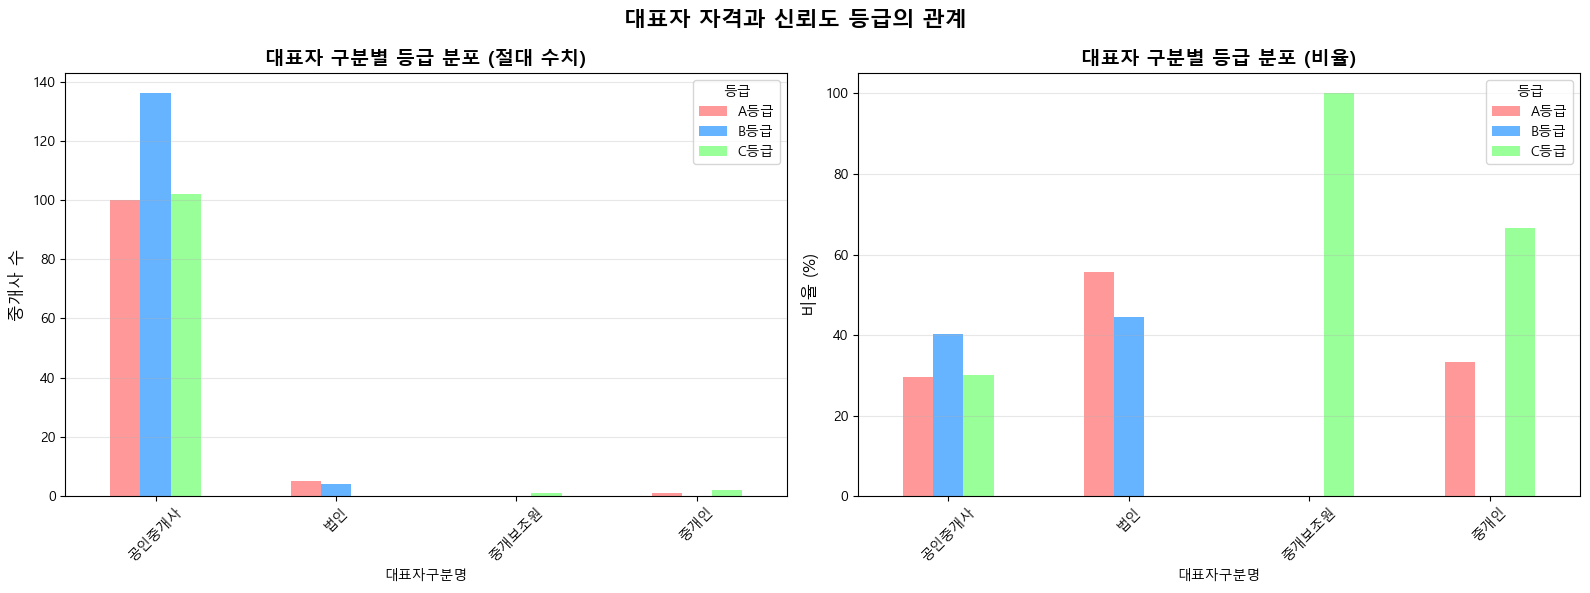


📊 대표자 구분별 평균 성과:
  공인중개사:
    - 평균 거래완료: 173.5건
    - 평균 등록매물: 53.2건
    - 평균 거래성사율: 0.530
  법인:
    - 평균 거래완료: 716.2건
    - 평균 등록매물: 73.9건
    - 평균 거래성사율: 0.708
  중개보조원:
    - 평균 거래완료: 10.0건
    - 평균 등록매물: 190.0건
    - 평균 거래성사율: 0.050
  중개인:
    - 평균 거래완료: 19.0건
    - 평균 등록매물: 10.7건
    - 평균 거래성사율: 0.479


In [46]:
# ============================================
# 4. 대표자 자격 vs 성과 연관성 분석
# ============================================
print("\n" + "="*70)
print("👨‍💼 대표자 자격 vs 성과 연관성 분석")
print("="*70)

# 대표자 구분별 등급 분포
rep_grade_crosstab = pd.crosstab(df_features['대표자구분명'], df_features['신뢰도등급'])
rep_grade_pct = rep_grade_crosstab.div(rep_grade_crosstab.sum(axis=1), axis=0) * 100

print("📊 대표자 구분별 등급 분포:")
print(rep_grade_crosstab)
print("\n📊 대표자 구분별 등급 비율 (%):")
print(rep_grade_pct.round(1))

# 통계적 유의성 검정
chi2_rep, p_value_rep = stats.chi2_contingency(rep_grade_crosstab)[:2]
print(f"\n🔍 카이제곱 검정 결과:")
print(f"  - 카이제곱 통계량: {chi2_rep:.3f}")
print(f"  - p-value: {p_value_rep:.6f}")
print(f"  - 유의성: {'유의함 (p<0.05)' if p_value_rep < 0.05 else '유의하지 않음 (p≥0.05)'}")

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 절대 수치
rep_grade_crosstab.plot(kind='bar', ax=axes[0], color=['#ff9999', '#66b3ff', '#99ff99'])
axes[0].set_title('대표자 구분별 등급 분포 (절대 수치)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('중개사 수', fontsize=12)
axes[0].legend(title='등급', labels=['A등급', 'B등급', 'C등급'])
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(True, alpha=0.3, axis='y')

# 비율
rep_grade_pct.plot(kind='bar', ax=axes[1], color=['#ff9999', '#66b3ff', '#99ff99'])
axes[1].set_title('대표자 구분별 등급 분포 (비율)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('비율 (%)', fontsize=12)
axes[1].legend(title='등급', labels=['A등급', 'B등급', 'C등급'])
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(True, alpha=0.3, axis='y')

plt.suptitle('대표자 자격과 신뢰도 등급의 관계', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# 성과 지표별 분석
print(f"\n📊 대표자 구분별 평균 성과:")
for rep_type in df_features['대표자구분명'].unique():
    rep_data = df_features[df_features['대표자구분명'] == rep_type]
    avg_transaction = rep_data['거래완료_숫자'].mean()
    avg_listing = rep_data['등록매물_숫자'].mean()
    avg_success_rate = rep_data['거래성사율'].mean()
    
    print(f"  {rep_type}:")
    print(f"    - 평균 거래완료: {avg_transaction:.1f}건")
    print(f"    - 평균 등록매물: {avg_listing:.1f}건")
    print(f"    - 평균 거래성사율: {avg_success_rate:.3f}")
